# EXPLORATORY DATA ANALYSIS

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 200)

## Load data

In [3]:
DATA_PATH = '../data/train.csv'

def load_data(path: str) -> pd.DataFrame:
    path = Path(path)
    suffix = path.suffix.lower()

    if suffix == '.csv':
        return pd.read_csv(path)
    if suffix in ['.xls', '.xlsx']:
        return pd.read_excel(path)
    if suffix == '.json':
        return pd.read_json(path)
    if suffix in ['.parquet', '.pq']:
        return pd.read_parquet(path)
    raise ValueError(f'Unsupported file format: {suffix}')

df = load_data(DATA_PATH)
print(df.head())

   id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  Sunlight_Hours  Wind_Speed_kmh  Crop_Type Crop_Growth_Stage  Season  \
0   0     Loamy     4.92          32.58            1.01                     3.05          15.01     50.61       725.99            5.90           16.79  Sugarcane            Sowing    Zaid   
1   1      Clay     7.08          56.61            0.44                     2.00          22.92     67.86       985.66            6.98            3.39      Wheat        Vegetative  Kharif   
2   2      Clay     5.69          27.71            0.81                     2.83          26.97     92.22      2201.70            6.05            3.85       Rice        Vegetative  Kharif   
3   3     Sandy     5.65          13.32            1.33                     0.87          13.32     61.57      1357.33            9.12            2.31      Wheat         Flowering  Kharif   
4   4      Clay     7.96          59.14      

## Initial inspection

In [4]:
display(df.sample(min(len(df), 10), random_state=42))

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes.rename('dtype').to_frame())

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
364426,364426,Sandy,4.87,38.18,1.37,0.29,21.43,83.74,2082.14,7.09,16.51,Cotton,Harvest,Zaid,Rainfed,Groundwater,3.53,No,114.18,East,Low
224752,224752,Loamy,5.89,49.28,1.39,3.11,22.91,44.62,1864.00,10.39,9.46,Sugarcane,Harvest,Rabi,Sprinkler,Reservoir,1.56,Yes,15.00,West,Low
110423,110423,Sandy,6.44,50.75,1.16,0.24,39.88,68.89,1194.07,9.73,15.52,Rice,Harvest,Zaid,Drip,Groundwater,13.45,Yes,20.48,East,Low
272555,272555,Silt,4.84,49.17,0.85,2.26,20.94,55.12,2033.44,10.78,19.58,Sugarcane,Flowering,Rabi,Rainfed,Reservoir,6.04,No,91.53,South,Medium
199651,199651,Sandy,5.82,44.72,0.41,0.81,41.49,41.30,2223.23,9.12,8.99,Rice,Sowing,Zaid,Sprinkler,Groundwater,13.45,No,70.41,North,Low
348918,348918,Silt,5.17,40.60,0.73,0.45,29.17,47.68,767.86,7.44,2.84,Maize,Vegetative,Rabi,Canal,Rainwater,0.74,Yes,24.31,East,Low
395208,395208,Clay,7.90,54.88,1.41,3.12,12.03,38.49,968.72,6.57,19.01,Sugarcane,Harvest,Rabi,Sprinkler,Rainwater,3.10,No,112.45,East,Low
254046,254046,Loamy,7.39,36.33,0.38,2.93,18.20,46.23,2134.91,8.24,12.90,Potato,Sowing,Zaid,Sprinkler,River,1.19,Yes,59.67,West,Low
401796,401796,Loamy,8.16,21.85,0.43,1.99,27.54,63.24,2175.00,10.84,13.25,Sugarcane,Harvest,Kharif,Canal,River,5.85,No,103.75,Central,Medium
373978,373978,Loamy,7.40,22.11,1.55,0.75,18.15,84.15,1814.94,7.94,6.22,Potato,Sowing,Rabi,Canal,Reservoir,9.93,No,26.12,North,Low



Column names:
['id', 'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']

Data types:
                           dtype
id                         int64
Soil_Type                 object
Soil_pH                  float64
Soil_Moisture            float64
Organic_Carbon           float64
Electrical_Conductivity  float64
Temperature_C            float64
Humidity                 float64
Rainfall_mm              float64
Sunlight_Hours           float64
Wind_Speed_kmh           float64
Crop_Type                 object
Crop_Growth_Stage         object
Season                    object
Irrigation_Type           object
Water_Source              object
Field_Area_hectare       float64
Mulching_Used             object

## Missing value analysis

In [5]:
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]

if missing.empty:
    print("\nNo missing values.")
else:
    ax = missing.plot(kind='bar', figsize=(12, 5))
    ax.set_title('Proportion of Missing Values by Column')
    ax.set_ylabel('Proportion Missing')
    ax.set_xlabel('Column')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    display((missing * 100).round(2).rename('missing_pct').to_frame())


No missing values.


## Numerical and categorical column detection

In [6]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")


Numerical columns (12): ['id', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
Categorical columns (9): ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region', 'Irrigation_Need']


## Numeric summaries

In [7]:
if numerical_cols:
    print("\nNumerical column statistics:")
    display(df[numerical_cols].describe().T)


Numerical column statistics:


,count,mean,std,min,25%,50%,75%,max
id,630000.0,314999.500000,181865.479132,0.00,157499.7500,314999.50,472499.25,629999.00
Soil_pH,630000.0,6.482497,0.922504,4.80,5.6900,6.44,7.27,8.20
Soil_Moisture,630000.0,37.304482,16.377082,8.00,23.3400,37.75,51.27,64.99
Organic_Carbon,630000.0,0.922858,0.365808,0.30,0.6100,0.91,1.22,1.60
Electrical_Conductivity,630000.0,1.744605,0.952321,0.10,0.9300,1.74,2.58,3.50
Temperature_C,630000.0,26.998166,8.623621,12.00,19.5175,26.96,34.54,42.00
Humidity,630000.0,61.563180,19.708152,25.00,45.3900,61.65,79.12,94.99
Rainfall_mm,630000.0,1462.207566,612.989738,0.38,954.5700,1467.16,2054.28,2499.69
Sunlight_Hours,630000.0,7.513382,1.999322,4.00,5.7600,7.58,9.25,11.00
Wind_Speed_kmh,630000.0,10.375394,5.689458,0.50,5.2800,10.48,15.43,20.00


## Categorical summaries

In [8]:
MAX_LEVELS_TO_SHOW = 15

if categorical_cols:
    print("\nCategorical column value counts:")
    for col in categorical_cols:
        print(f"\nColumn: {col}")
        value_counts = df[col].value_counts(dropna=False)
        if len(value_counts) > MAX_LEVELS_TO_SHOW:
            print(f"  Too many levels ({len(value_counts)}), showing top {MAX_LEVELS_TO_SHOW}:")
            display(value_counts.head(MAX_LEVELS_TO_SHOW).to_frame())
        else:
            display(value_counts.to_frame())


Categorical column value counts:

Column: Soil_Type


,count
Soil_Type,
Sandy,166509
Clay,158470
Loamy,156455
Silt,148566



Column: Crop_Type


,count
Crop_Type,
Sugarcane,108910
Rice,106697
Cotton,104645
Maize,104274
Wheat,103005
Potato,102469



Column: Crop_Growth_Stage


...

,count
Mulching_Used,
No,316453
Yes,313547



Column: Region


,count
Region,
South,134809
West,131189
East,126163
Central,123712
North,114127



Column: Irrigation_Need


,count
Irrigation_Need,
Low,369917
Medium,239074
High,21009


## Distribution plots and box plots for numeric columns

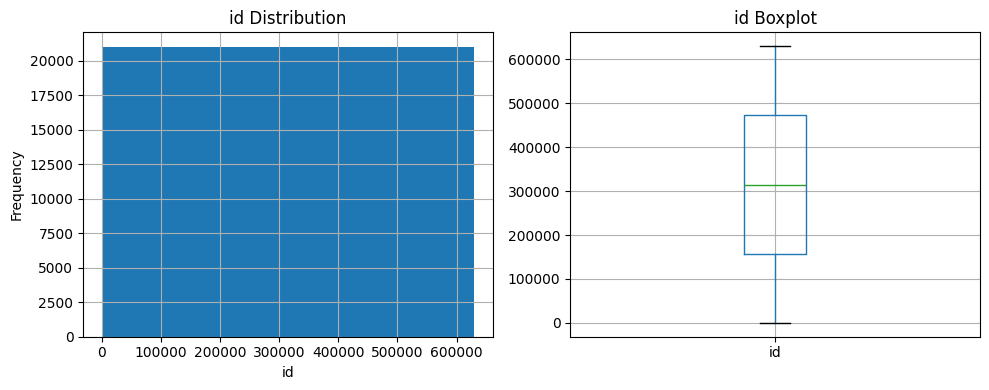

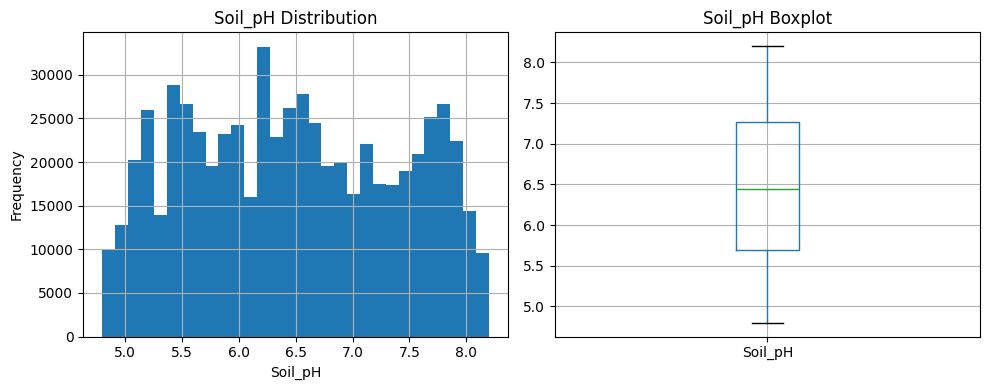

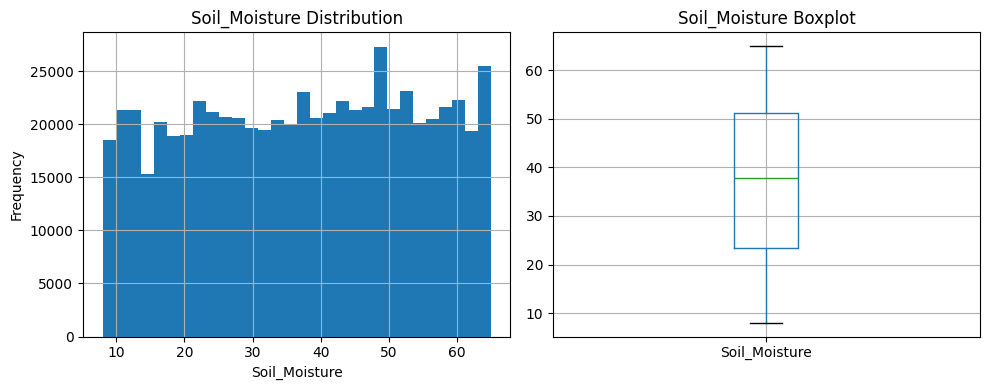

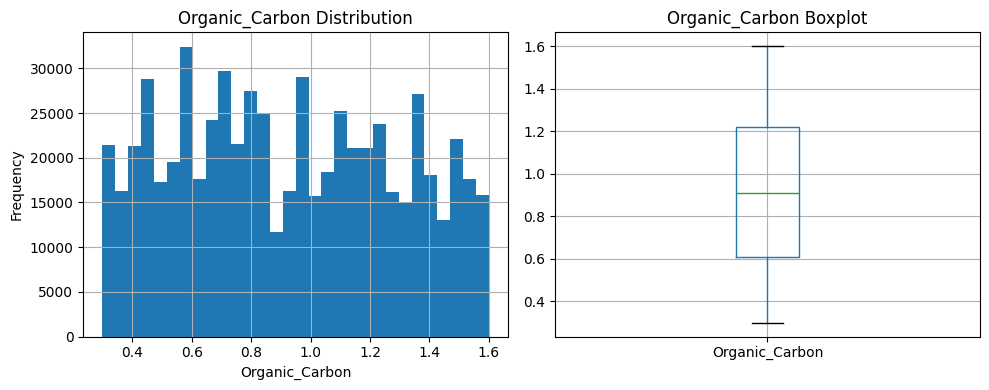

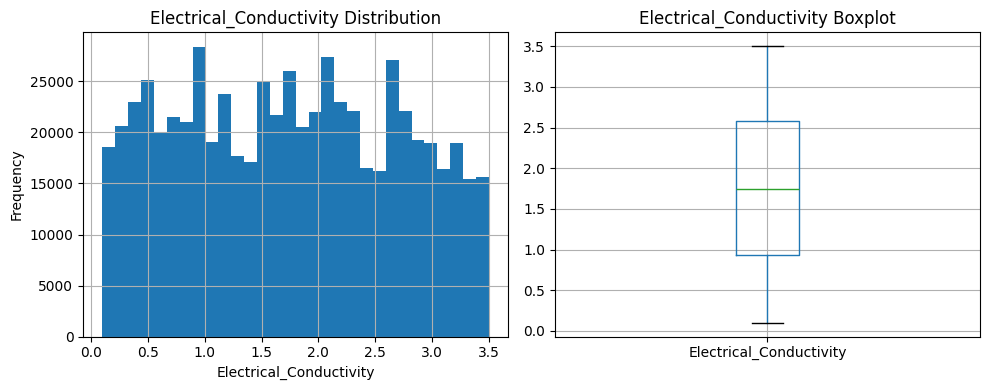

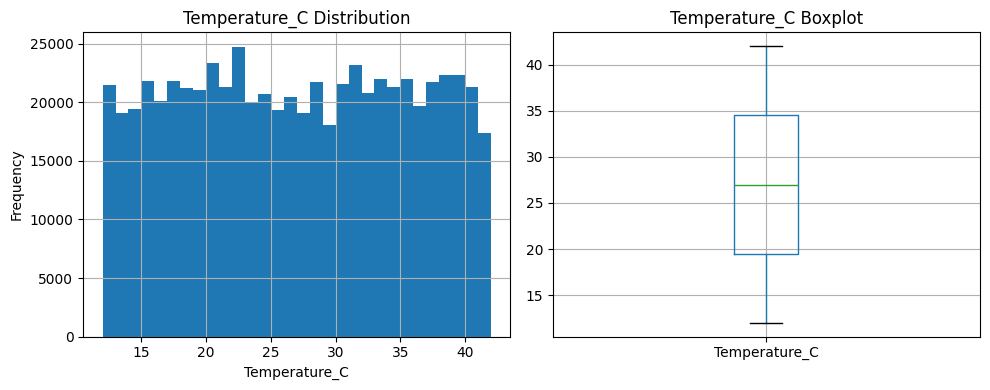

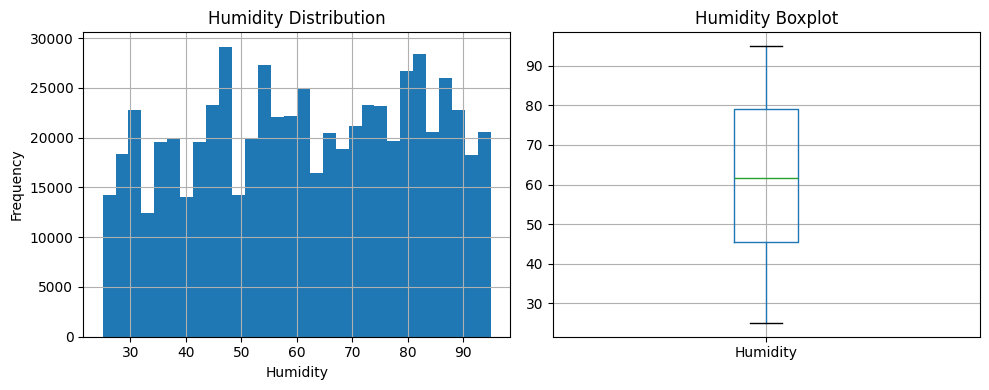

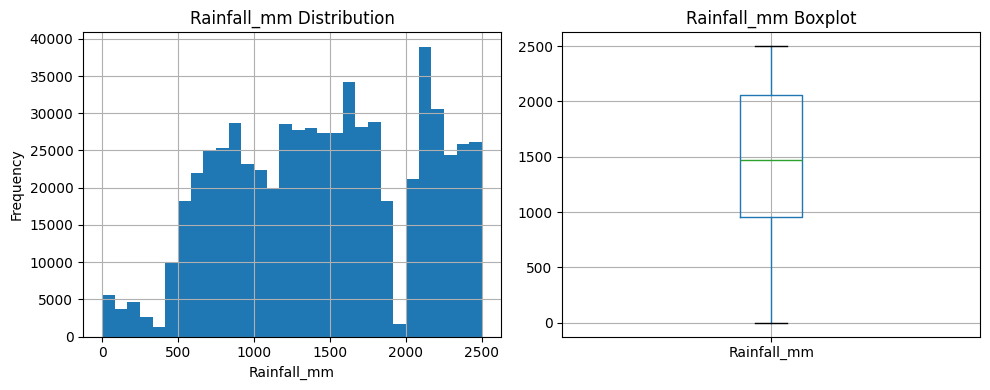

In [9]:
PLOT_NUMERIC_LIMIT = 8
cols_to_plot = numerical_cols[:PLOT_NUMERIC_LIMIT]

for col in cols_to_plot:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    df[col].hist(bins=30)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    df.boxplot(column=col)
    plt.title(f'{col} Boxplot')

    plt.tight_layout()
    plt.show()

## Correlation analysis

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
id,1.000000,0.001298,0.000773,0.000390,-0.001213,0.001505,0.001669,0.000245,0.000468,0.000142,0.000960,0.000026
Soil_pH,0.001298,1.000000,-0.003547,-0.002973,-0.000171,-0.002402,0.001374,-0.004799,0.000586,0.002978,0.004335,0.002216
Soil_Moisture,0.000773,-0.003547,1.000000,-0.015072,-0.009136,-0.037891,0.015403,0.044473,0.005776,-0.027865,-0.005365,-0.023434
Organic_Carbon,0.000390,-0.002973,-0.015072,1.000000,0.010919,-0.001954,0.003093,-0.017391,-0.000438,0.011341,-0.006283,-0.000549
Electrical_Conductivity,-0.001213,-0.000171,-0.009136,0.010919,1.000000,0.003641,0.000256,-0.004025,0.000111,-0.001637,0.007656,0.001652
Temperature_C,0.001505,-0.002402,-0.037891,-0.001954,0.003641,1.000000,-0.020448,-0.016767,-0.003049,-0.002041,0.010836,0.008232
Humidity,0.001669,0.001374,0.015403,0.003093,0.000256,-0.020448,1.000000,0.000596,0.001786,0.011738,0.005706,0.018669
Rainfall_mm,0.000245,-0.004799,0.044473,-0.017391,-0.004025,-0.016767,0.000596,1.000000,-0.006219,-0.032776,-0.011578,0.013207
Sunlight_Hours,0.000468,0.000586,0.005776,-0.000438,0.000111,-0.003049,0.001786,-0.006219,1.000000,0.000134,-0.004999,0.002426
Wind_Speed_kmh,0.000142,0.002978,-0.027865,0.011341,-0.001637,-0.002041,0.011738,-0.032776,0.000134,1.000000,0.009671,0.009510


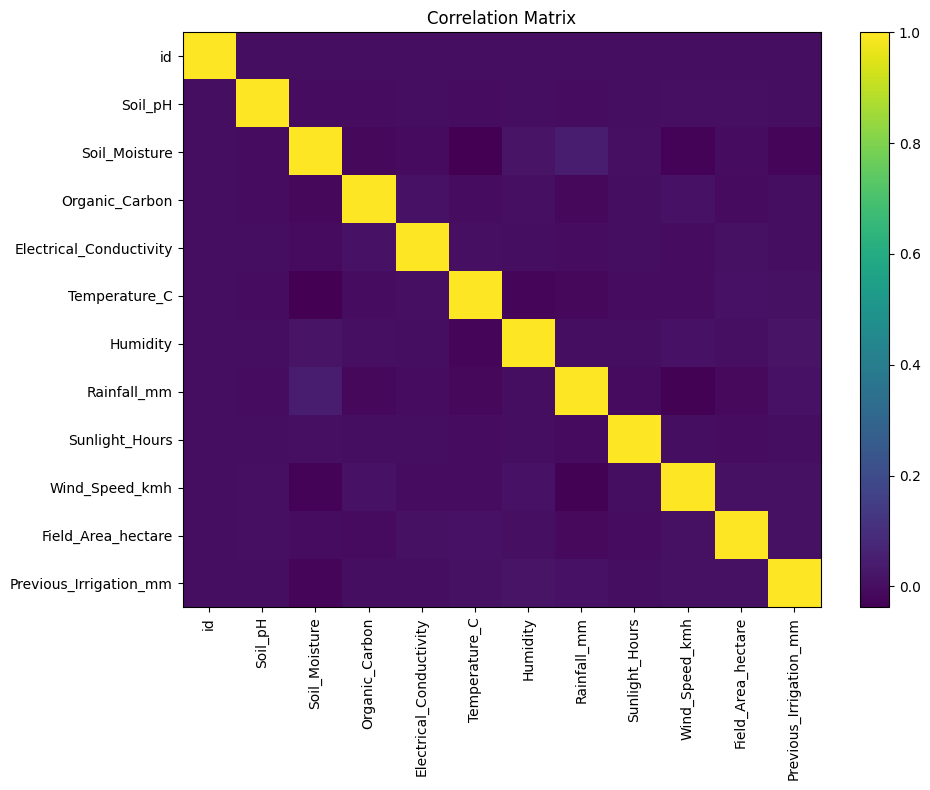

In [10]:
if len(numerical_cols) >= 2:
    corr = df[numerical_cols].corr(numeric_only=True)
    display(corr)

    plt.figure(figsize=(10, 8))
    plt.imshow(corr, aspect='auto')
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()
else:
    print("\nNot enough numerical columns to compute correlation matrix.")

## Scatter plots for top correlated pairs

abs_corr
Soil_Moisture Rainfall_mm             0.044473
              Temperature_C           0.037891
Rainfall_mm   Wind_Speed_kmh          0.032776
Soil_Moisture Wind_Speed_kmh          0.027865
              Previous_Irrigation_mm  0.023434

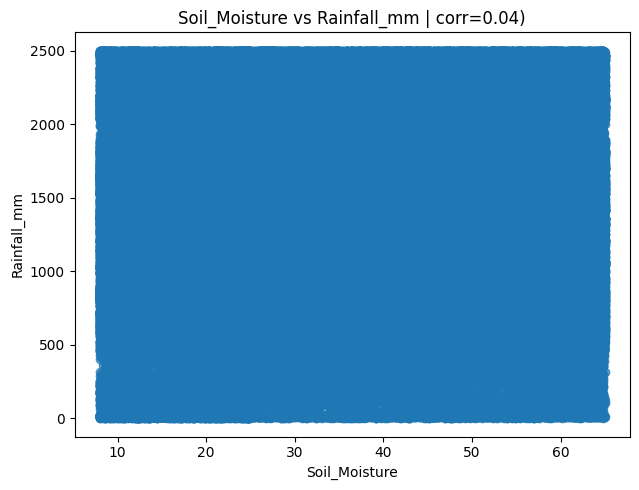

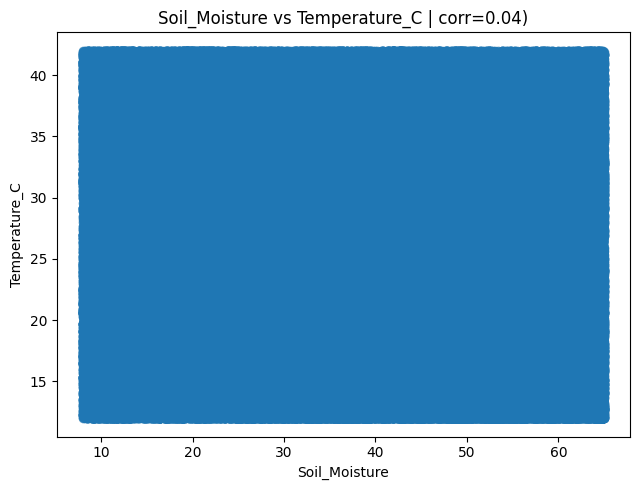

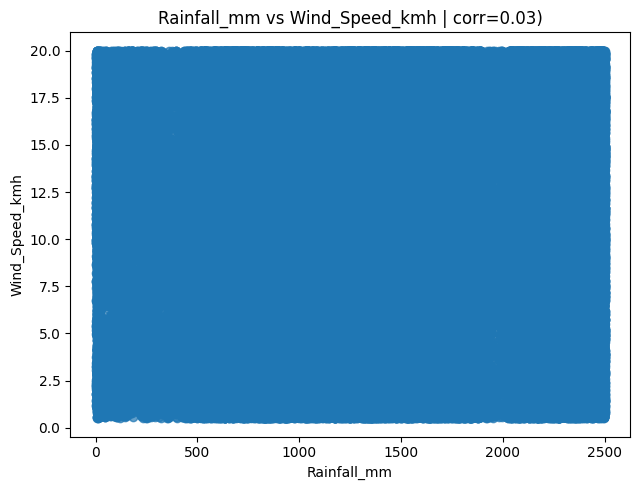

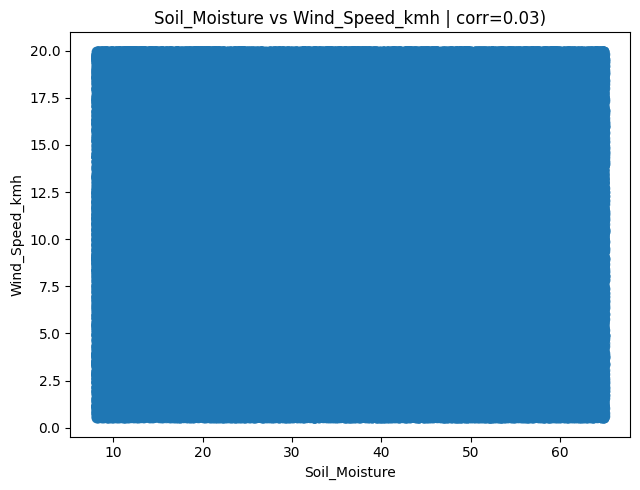

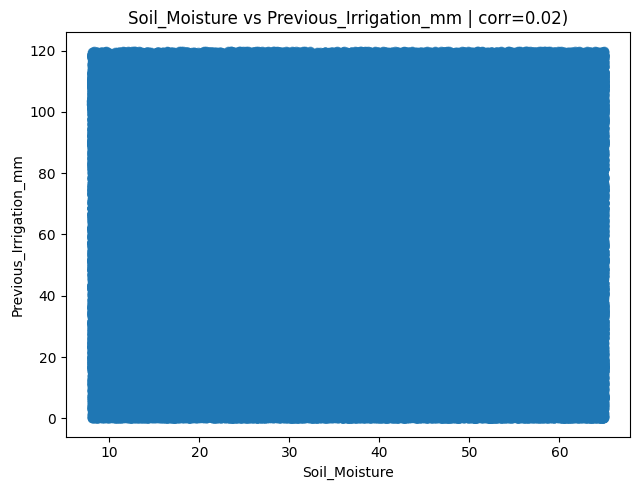

In [11]:
if len(numerical_cols) >= 2:
    corr_abs = df[numerical_cols].corr(numeric_only=True).abs()
    upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
    pairs = upper.stack().sort_values(ascending=False)

    top_pairs = pairs.head(5)
    display(top_pairs.rename('abs_corr').to_frame())

    for (x_col, y_col), corr_value in top_pairs.items():
        plt.figure(figsize=(6.5, 5))
        plt.scatter(df[x_col], df[y_col], alpha=0.7)
        plt.title(f'{x_col} vs {y_col} | corr={corr_value:.2f})')
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.tight_layout()
        plt.show()

else:
    print("\nNot enough numerical columns to analyze pairwise correlations.")

## Grouped numeric comparisons by category

,count,mean,median
Soil_Type,,,
Sandy,166509,6.484006,6.44
Clay,158470,6.484046,6.45
Loamy,156455,6.485210,6.45
Silt,148566,6.476298,6.44


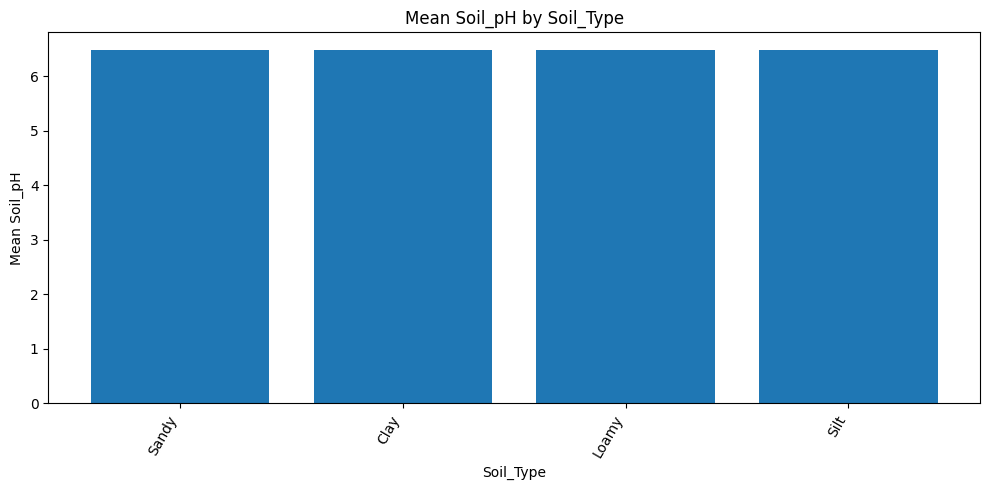

In [12]:
if categorical_cols and numerical_cols:
    cat_col = categorical_cols[0]
    num_col = numerical_cols[1]

    grouped = (
        df.groupby(cat_col, dropna=False)[num_col]
        .agg(['count', 'mean', 'median'])
        .sort_values('count', ascending=False)
        .head(15)
    )
    display(grouped)
        
    plt.figure(figsize=(10, 5))
    plt.bar(grouped.index.astype(str), grouped['mean'])
    plt.title(f'Mean {num_col} by {cat_col}')
    plt.xlabel(cat_col)
    plt.ylabel(f'Mean {num_col}')
    plt.xticks(rotation=60, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("\nNot enough categorical or numerical columns to analyze group statistics.")

In [15]:
pd.crosstab(df['Crop_Type'], df['Soil_Type'], dropna=False)

Soil_Type,Clay,Loamy,Sandy,Silt
Crop_Type,,,,
Cotton,27540,24264,27681,25160
Maize,25906,26160,26692,25516
Potato,24446,26199,28099,23725
Rice,27342,27046,28233,24076
Sugarcane,28011,27439,28150,25310
Wheat,25225,25347,27654,24779


In [16]:
from itertools import combinations

for col1, col2 in combinations(categorical_cols, 2):
    print(f"\n=== {col1} vs {col2} (cross-tabulation) ===")
    display(pd.crosstab(df[col1], df[col2], normalize='index'))


=== Soil_Type vs Crop_Type (cross-tabulation) ===


Crop_Type,Cotton,Maize,Potato,Rice,Sugarcane,Wheat
Soil_Type,,,,,,
Clay,0.173787,0.163476,0.154263,0.172537,0.176759,0.159178
Loamy,0.155086,0.167205,0.167454,0.172868,0.175380,0.162008
Sandy,0.166243,0.160304,0.168754,0.169558,0.169060,0.166081
Silt,0.169352,0.171749,0.159693,0.162056,0.170362,0.166788



=== Soil_Type vs Crop_Growth_Stage (cross-tabulation) ===


Crop_Growth_Stage,Flowering,Harvest,Sowing,Vegetative
Soil_Type,,,,
Clay,0.258983,0.265754,0.235262,0.240001
Loamy,0.242006,0.269707,0.241104,0.247183
Sandy,0.246065,0.259704,0.232108,0.262124
Silt,0.253672,0.270149,0.227845,0.248334



=== Soil_Type vs Season (cross-tabulation) ===


...

Region,Central,East,North,South,West
Mulching_Used,,,,,
No,0.198788,0.197745,0.186201,0.207794,0.209472
Yes,0.193926,0.202796,0.176060,0.220229,0.206990



=== Mulching_Used vs Irrigation_Need (cross-tabulation) ===


Irrigation_Need,High,Low,Medium
Mulching_Used,,,
No,0.058527,0.445046,0.496428
Yes,0.007935,0.730611,0.261454



=== Region vs Irrigation_Need (cross-tabulation) ===


Irrigation_Need,High,Low,Medium
Region,,,
Central,0.034354,0.593014,0.372632
East,0.028701,0.593462,0.377837
North,0.034278,0.576253,0.389470
South,0.034753,0.586526,0.378721
West,0.034614,0.585766,0.379620


In [17]:
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

results = []

for col1, col2 in combinations(categorical_cols, 2):
    value = cramers_v(df[col1], df[col2])
    results.append((col1, col2, value))

# Sort by strongest relationships
results = sorted(results, key=lambda x: x[2], reverse=True)

pd.DataFrame(results, columns=['Feature 1', 'Feature 2', "Cramér's V"])

,Feature 1,Feature 2,Cramér's V
0,Crop_Growth_Stage,Irrigation_Need,0.392771
1,Mulching_Used,Irrigation_Need,0.300468
2,Crop_Growth_Stage,Mulching_Used,0.065594
3,Irrigation_Type,Mulching_Used,0.036303
4,Water_Source,Irrigation_Need,0.036107
5,Season,Mulching_Used,0.031209
6,Irrigation_Type,Irrigation_Need,0.029499
7,Crop_Type,Irrigation_Need,0.029479
8,Season,Irrigation_Type,0.027277
9,Crop_Type,Season,0.023815
